In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn import metrics
import pickle

In [2]:
data=pd.read_csv('out.csv')

In [3]:
data=data.sample(frac=1)
data.drop(['Unnamed: 0','Shape','active_channel_count','root','Gas_Type','avg'],axis=1,inplace=True)
#data= data.set_index('Event')
data

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
88,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,3500,kaynaksız,1.52,0
192,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,6.00,36.00,0.36,7000,kaynaksız,1.52,0
26,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,6.00,36.00,0.36,4000,cs,1.52,8
84,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,4500,kaynaksız,1.52,3
153,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,6500,cs,1.52,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,7500,kaynaksız,1.52,95
183,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,4500,kaynaksız,1.52,0
212,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,6.00,36.00,0.36,6000,kaynaksız,1.52,0
209,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,6.00,36.00,0.36,7500,kaynaksız,1.52,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 273 entries, 88 to 46
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CH4               273 non-null    float64
 1   Ar                273 non-null    float64
 2   N2                273 non-null    float64
 3   CO2               273 non-null    float64
 4   C                 273 non-null    float64
 5   O                 273 non-null    float64
 6   H                 273 non-null    float64
 7   Detector_Size     273 non-null    float64
 8   Detector_Area     273 non-null    float64
 9   Cover_Size        273 non-null    float64
 10  Cover_Area        273 non-null    float64
 11  Cover_Area_Ratio  273 non-null    float64
 12  Voltage           273 non-null    int64  
 13  Source            273 non-null    object 
 14  Time_Window       273 non-null    float64
 15  Peak_Count        273 non-null    int64  
dtypes: float64(13), int64(2), object(1)
memory usage:

In [5]:
data.isnull()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
88,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
192,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
26,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
84,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
153,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
183,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
212,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
209,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
data.isnull().sum()

CH4                 0
Ar                  0
N2                  0
CO2                 0
C                   0
O                   0
H                   0
Detector_Size       0
Detector_Area       0
Cover_Size          0
Cover_Area          0
Cover_Area_Ratio    0
Voltage             0
Source              0
Time_Window         0
Peak_Count          0
dtype: int64

<Axes: >

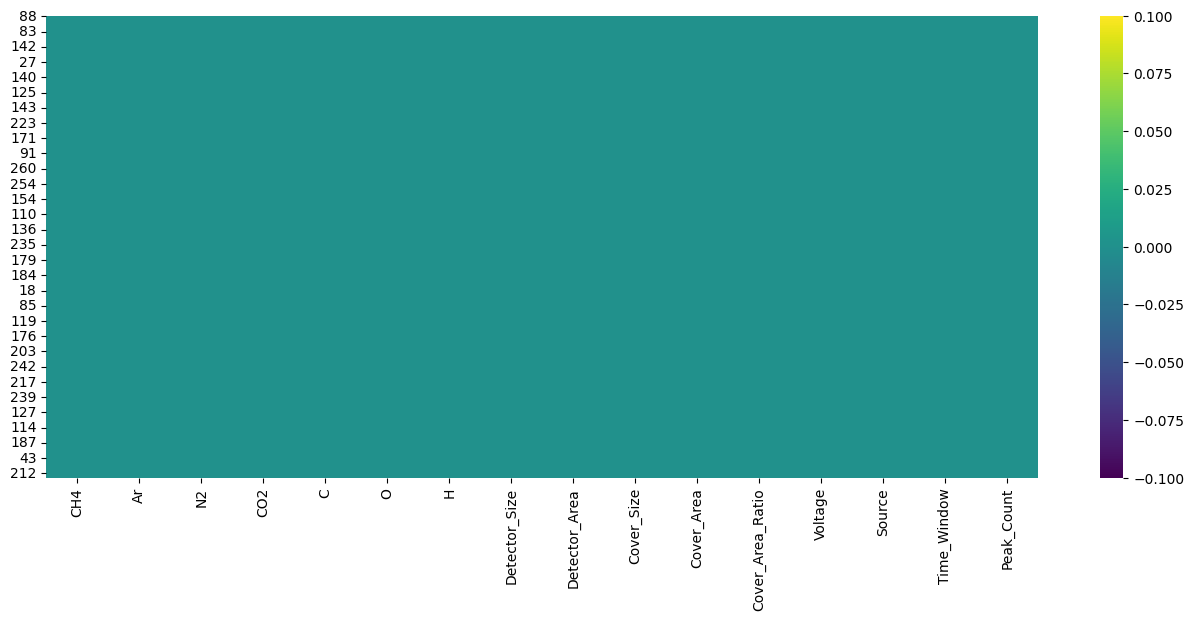

In [7]:
plt.figure(figsize=(16, 6))
sns.heatmap(data.isnull(),cmap='viridis')

In [8]:
data.dropna(inplace=True)

In [9]:
data.isnull().sum()

CH4                 0
Ar                  0
N2                  0
CO2                 0
C                   0
O                   0
H                   0
Detector_Size       0
Detector_Area       0
Cover_Size          0
Cover_Area          0
Cover_Area_Ratio    0
Voltage             0
Source              0
Time_Window         0
Peak_Count          0
dtype: int64

In [10]:
data.head()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
88,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,3500,kaynaksız,1.52,0
192,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,6.00,36.00,0.36,7000,kaynaksız,1.52,0
26,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,6.00,36.00,0.36,4000,cs,1.52,8
84,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,4500,kaynaksız,1.52,3
153,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,6500,cs,1.52,38


In [11]:
type2=pd.get_dummies(data['Source'],drop_first=True,dtype=float)
type2

,kaynaksız
88,1.0
192,1.0
26,0.0
84,1.0
153,0.0
...,...
267,1.0
183,1.0
212,1.0
209,1.0


In [12]:
type=pd.get_dummies(data['Source'],drop_first=True,dtype=float)
type

,kaynaksız
88,1.0
192,1.0
26,0.0
84,1.0
153,0.0
...,...
267,1.0
183,1.0
212,1.0
209,1.0


In [13]:
data=pd.concat([data,type2],axis=1)
data.head()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count,kaynaksız
88,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,3500,kaynaksız,1.52,0,1.0
192,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,6.00,36.00,0.36,7000,kaynaksız,1.52,0,1.0
26,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,6.00,36.00,0.36,4000,cs,1.52,8,0.0
84,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,4500,kaynaksız,1.52,3,1.0
153,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,6500,cs,1.52,38,0.0


In [14]:
#sns.set(style="ticks", color_codes=True)
#g = sns.pairplot(data)
#plt.show()

In [15]:
data.drop(['Source'],axis=1,inplace=True)
data.head()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,Peak_Count,kaynaksız
88,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,3500,1.52,0,1.0
192,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,6.00,36.00,0.36,7000,1.52,0,1.0
26,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,6.00,36.00,0.36,4000,1.52,8,0.0
84,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,4500,1.52,3,1.0
153,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,6500,1.52,38,0.0


In [16]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 273 entries, 88 to 46
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CH4               273 non-null    float64
 1   Ar                273 non-null    float64
 2   N2                273 non-null    float64
 3   CO2               273 non-null    float64
 4   C                 273 non-null    float64
 5   O                 273 non-null    float64
 6   H                 273 non-null    float64
 7   Detector_Size     273 non-null    float64
 8   Detector_Area     273 non-null    float64
 9   Cover_Size        273 non-null    float64
 10  Cover_Area        273 non-null    float64
 11  Cover_Area_Ratio  273 non-null    float64
 12  Voltage           273 non-null    int64  
 13  Time_Window       273 non-null    float64
 14  Peak_Count        273 non-null    int64  
 15  kaynaksız         273 non-null    float64
dtypes: float64(14), int64(2)
memory usage: 36.3 KB


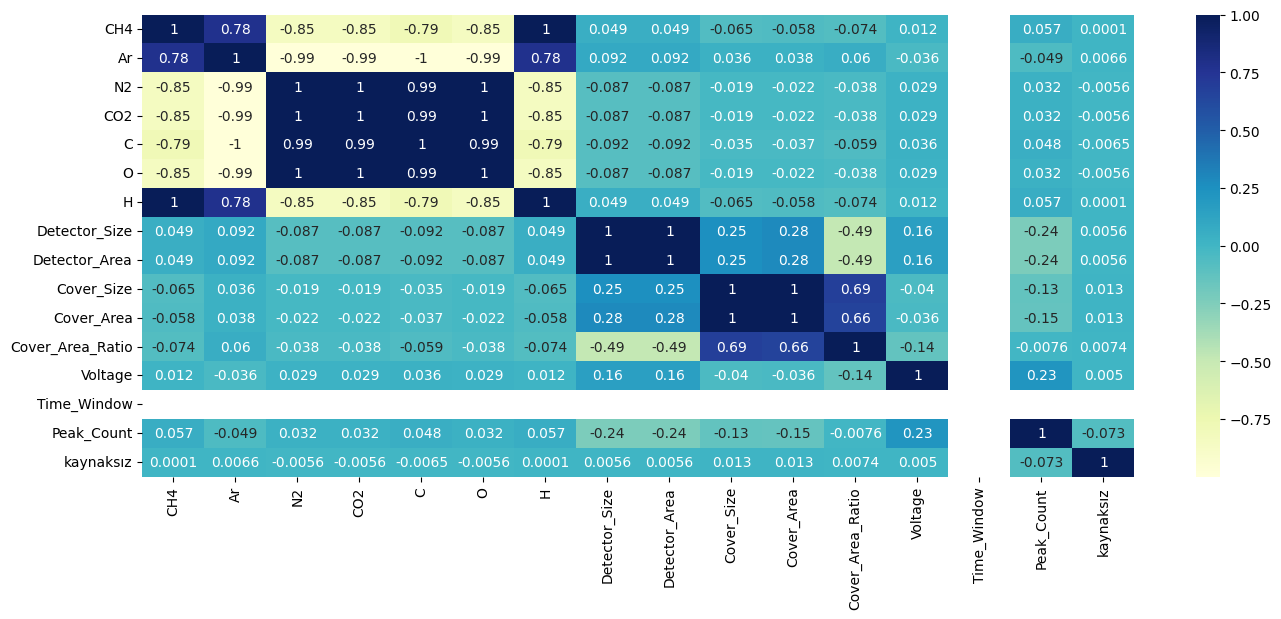

In [17]:
# creation of correlation matrix
corrM = data.corr()
plt.figure(figsize=(16, 6))
dataplot = sns.heatmap(corrM, cmap="YlGnBu", annot=True) 


In [18]:
corrM[abs(corrM['Peak_Count'])>0.1][['Peak_Count']]

,Peak_Count
Detector_Size,-0.240341
Detector_Area,-0.240341
Cover_Size,-0.133875
Cover_Area,-0.145378
Voltage,0.225220
Peak_Count,1.000000


In [19]:
from sklearn.model_selection import train_test_split

In [20]:
x=data.drop(['Peak_Count'],axis=1)
#x=data[['Detector_Size','Detector_Area','Cover_Size','Cover_Area','Voltage','kaynaksız']]

x.head()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,kaynaksız
88,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,3500,1.52,1.0
192,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,6.00,36.00,0.36,7000,1.52,1.0
26,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,6.00,36.00,0.36,4000,1.52,0.0
84,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,4500,1.52,1.0
153,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,6500,1.52,0.0


In [21]:
y=data['Peak_Count']
y

88      0
192     0
26      8
84      3
153    38
       ..
267    95
183     0
212     0
209     1
46      6
Name: Peak_Count, Length: 273, dtype: int64

In [22]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
model=LinearRegression()

In [25]:
model.fit(X_train,y_train)

LinearRegression()

In [26]:
pred=model.predict(X_test)
pred

array([-38.36719024,  31.89256753,  78.42983301,  13.28344561,
        17.19956098,   9.09370666,  80.6672454 ,  13.16421071,
       133.01488034,  63.79798889,  -9.87451494,  53.59748657,
        70.96582742,  57.19645229,  34.0688175 ,  65.63108055,
        36.72823006,  69.10672711,  70.37351684,  19.7657473 ,
         5.16596701, -36.179316  ,  87.24277335, -36.50808993,
        38.37486922,   6.99474157,  28.79268614,  40.64434544,
         8.85384189,  72.20660849,  17.64756981,  77.54135536,
       114.40575842,  16.28755384,  21.62484761,  19.38743523,
        51.26684794,  38.49410413,  62.53119916,  30.05947587,
       -29.93256199,   8.76493273,  72.32584339, -24.88467114,
        90.93496532,   7.85292559,  97.53650191,  63.89121514,
         1.62970107,  42.59235491, -55.23644675,  15.7884695 ,
        -8.10432378,  37.2273144 ,  21.71807386])

In [27]:
y_test

50       3
110      0
150     17
200      0
144     16
158     10
248    162
125      0
189    371
263     43
100      2
209      1
14      38
115     43
131     19
109     22
194      0
4       59
271     25
246    393
214      0
70       0
245     79
37       1
166      0
83       8
23      10
141      8
99       5
105     30
225      0
0       26
251    149
59      27
249     30
152     11
145      5
261    174
19      35
269    424
35       5
136     53
197     12
104      0
123     72
72      24
260    109
211      0
15       2
95      24
49       0
224      3
127      1
10      10
205      0
Name: Peak_Count, dtype: int64

In [28]:
X_test

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,kaynaksız
50,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,4.00,16.00,0.16,3500,1.52,1.0
110,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,6.00,36.00,0.36,4000,1.52,0.0
150,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,8000,1.52,0.0
200,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,6.00,36.00,0.36,4500,1.52,0.0
144,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,4.00,16.00,0.16,5500,1.52,0.0
158,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,4500,1.52,1.0
248,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,6000,1.52,0.0
125,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,6.00,36.00,0.36,3500,1.52,1.0
189,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,7500,1.52,0.0
263,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,5000,1.52,0.0


In [29]:
model.score(X_test, y_test)

0.10390046661316821

In [30]:
pred

array([-38.36719024,  31.89256753,  78.42983301,  13.28344561,
        17.19956098,   9.09370666,  80.6672454 ,  13.16421071,
       133.01488034,  63.79798889,  -9.87451494,  53.59748657,
        70.96582742,  57.19645229,  34.0688175 ,  65.63108055,
        36.72823006,  69.10672711,  70.37351684,  19.7657473 ,
         5.16596701, -36.179316  ,  87.24277335, -36.50808993,
        38.37486922,   6.99474157,  28.79268614,  40.64434544,
         8.85384189,  72.20660849,  17.64756981,  77.54135536,
       114.40575842,  16.28755384,  21.62484761,  19.38743523,
        51.26684794,  38.49410413,  62.53119916,  30.05947587,
       -29.93256199,   8.76493273,  72.32584339, -24.88467114,
        90.93496532,   7.85292559,  97.53650191,  63.89121514,
         1.62970107,  42.59235491, -55.23644675,  15.7884695 ,
        -8.10432378,  37.2273144 ,  21.71807386])

In [31]:
y_test

50       3
110      0
150     17
200      0
144     16
158     10
248    162
125      0
189    371
263     43
100      2
209      1
14      38
115     43
131     19
109     22
194      0
4       59
271     25
246    393
214      0
70       0
245     79
37       1
166      0
83       8
23      10
141      8
99       5
105     30
225      0
0       26
251    149
59      27
249     30
152     11
145      5
261    174
19      35
269    424
35       5
136     53
197     12
104      0
123     72
72      24
260    109
211      0
15       2
95      24
49       0
224      3
127      1
10      10
205      0
Name: Peak_Count, dtype: int64

In [32]:
indexes = X_test.index.values
len(indexes)

55

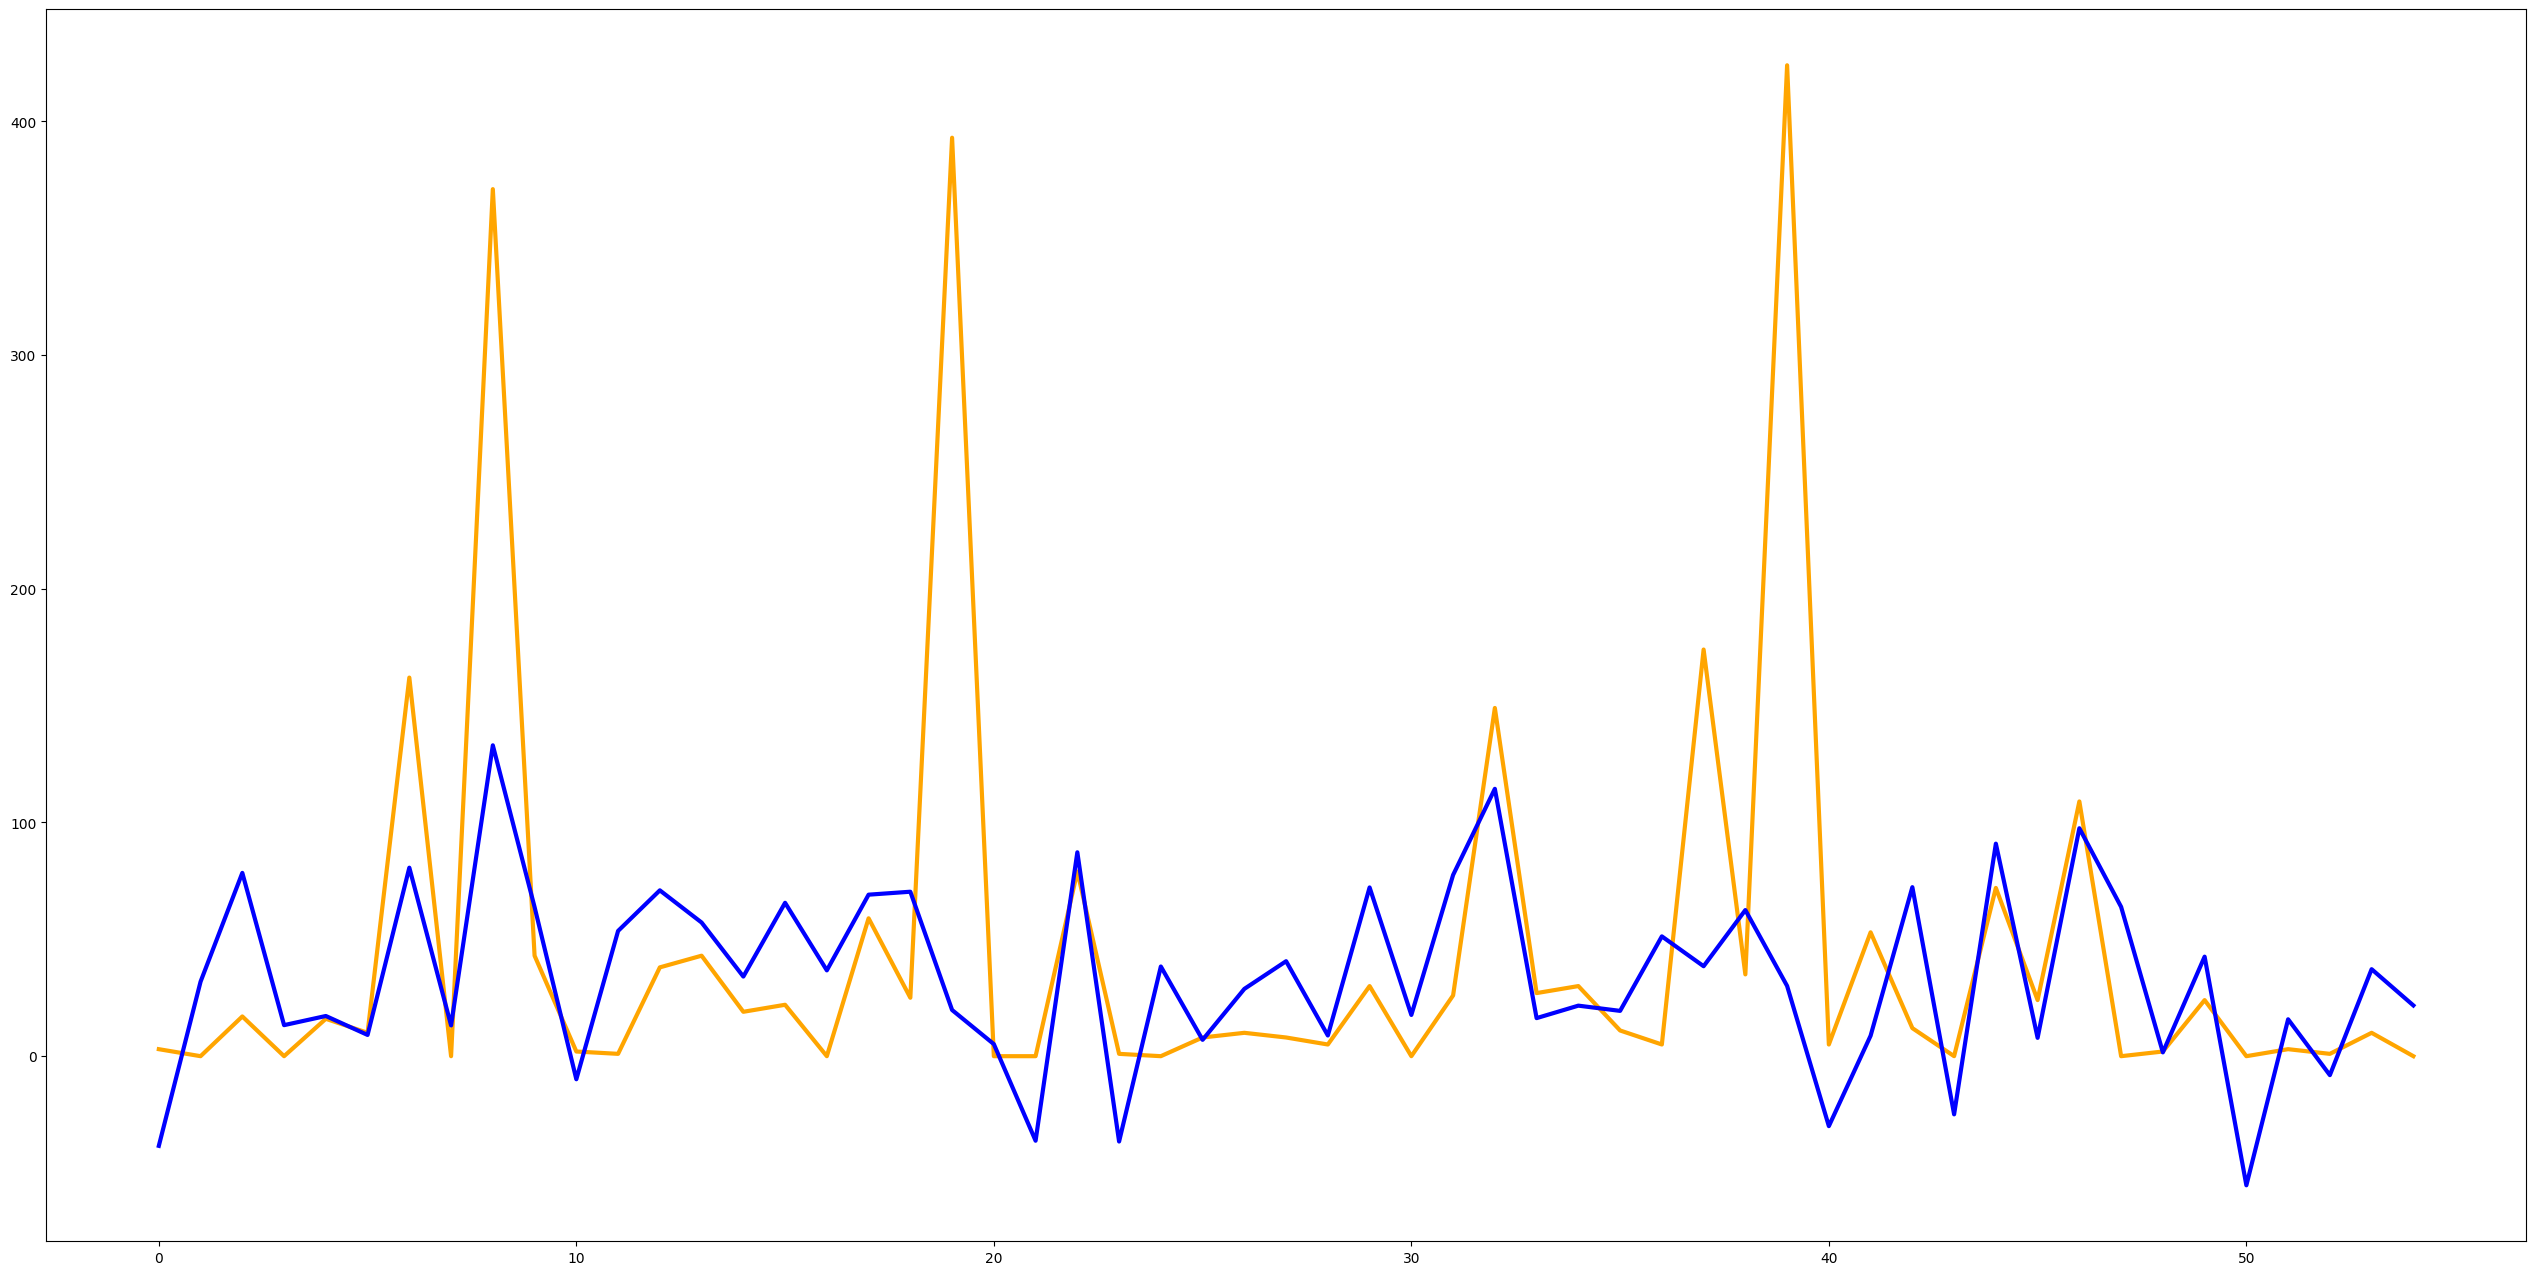

In [33]:
plt.figure(figsize=(32, 16))
plt.plot(range(0,len(indexes)),y_test, color="orange", linewidth=3)
plt.plot(range(0,len(indexes)),pred, color="blue", linewidth=3)
plt.show()